# 탐색적 데이터 분석(EDA : Exploratory Data Analysis)

- 통찰을 얻기 위한 데이터 분석의 가장 기본이 되는 방법

- 탐색적 데이터 분석의 과정
    1. 데이터 파악
        - 데이터의 외형적인 내용을 파악하는 단계
      
        - raw data : 분석에 활용된 적이 없는, 또는 정제되지 않은 데이터

        1. 데이터의 출처와 주제 파악
            - 데이터가 어디에서 생성된 것인지
            - 데이터가 어떻게 수집된 것인지
            - 예) 데이터의 이름, 구성 요소, 출처, 주제 등
        
        2. 데이터의 크기 파악
            - 데이터의 크기에 따라서 데이터의 처리 방식이 달라지기 때문
        
        3. 데이터의 구성 요소(피처) 파악
            - 데이터가 어떻게 구성되어 있는지, 어떤 정보를 담고 있는 지를 파악하는 아주 중요한 단계
            - 예) 신체 검사 데이터의 키, 몸무게, 시력, 청력 등
        
    2. 데이터의 속성 탐색
        - 데이터의 실제적인 내용을 파악하는 단계
        1. 피처의 속성 탐색
            - 피처 속성 탐색 단계에서 가장 중요한 것은 데이터에 질문을 던지는 것

        2. 피처 간의 상관관계 탐색
            - 여러 가지 피처가 서로에게 미치는 영향을 알아보는 단계
          
    3. 탐색한 데이터의 시각화
        - 지금까지 파악한 데이터를 효과적으로 시각화
      
        - 시각화는 수치적 자료만 가지고는 파악하기 힘든 패턴이나 통찰을 발견하는데에 유용

# 멕시코풍 프랜차이즈 chipotle 주문 데이터 분석

In [88]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## 데이터 파악 단계

In [89]:
data = pd.read_csv("./data/tsv/chipotle.tsv", sep = "\t")

In [90]:
# 전체 데이터 출력
data

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39
1,1,1,Izze,[Clementine],$3.39
2,1,1,Nantucket Nectar,[Apple],$3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98
...,...,...,...,...,...
4617,1833,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Black Beans, Sour ...",$11.75
4618,1833,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Sour Cream, Cheese...",$11.75
4619,1834,1,Chicken Salad Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Pinto...",$11.25
4620,1834,1,Chicken Salad Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Lettu...",$8.75


In [91]:
# 데이터의 앞 5행 출력
data.head()

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39
1,1,1,Izze,[Clementine],$3.39
2,1,1,Nantucket Nectar,[Apple],$3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98


In [92]:
# 데이터의 마지막 5행 출력
data.tail()

,order_id,quantity,item_name,choice_description,item_price
4617,1833,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Black Beans, Sour ...",$11.75
4618,1833,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Sour Cream, Cheese...",$11.75
4619,1834,1,Chicken Salad Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Pinto...",$11.25
4620,1834,1,Chicken Salad Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Lettu...",$8.75
4621,1834,1,Chicken Salad Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Pinto...",$8.75


In [93]:
# 데이터의 크기 확인 : 4622행 5열의 데이터
data.shape

(4622, 5)

In [94]:
# 데이터의 기본 정보 확인
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4622 entries, 0 to 4621
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   order_id            4622 non-null   int64 
 1   quantity            4622 non-null   int64 
 2   item_name           4622 non-null   object
 3   choice_description  3376 non-null   object
 4   item_price          4622 non-null   object
dtypes: int64(2), object(3)
memory usage: 180.7+ KB


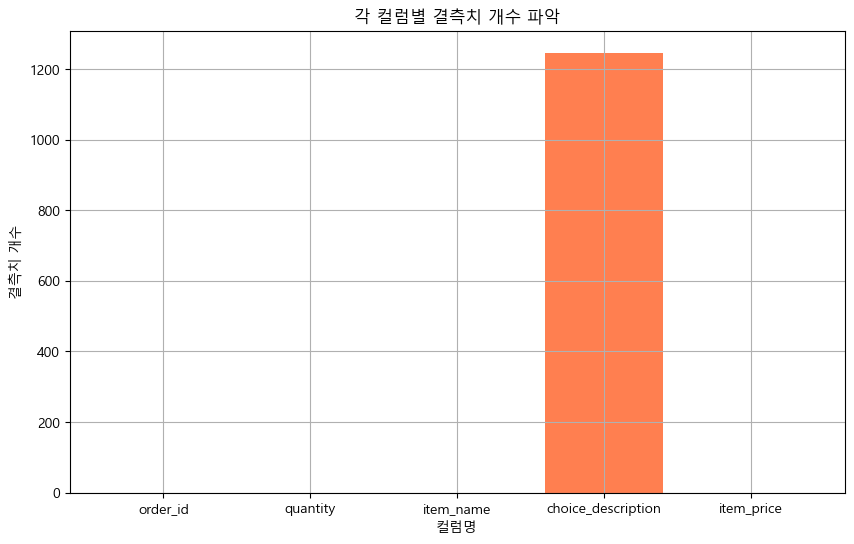

In [95]:
# 결측치 확인 시각화
missing_values = data.isnull().sum()

plt.figure(figsize=(10, 6))
plt.bar(missing_values.index, missing_values.values, color='coral')

plt.title('각 컬럼별 결측치 개수 파악')
plt.xlabel('컬럼명')
plt.ylabel('결측치 개수')
plt.grid()

plt.show()

In [96]:
# 데이터의 자료형 확인
data.dtypes

order_id               int64
quantity               int64
item_name             object
choice_description    object
item_price            object
dtype: object

In [97]:
# 데이터의 기술 통계 정보 확인
data.describe()

,order_id,quantity
count,4622.000000,4622.000000
mean,927.254868,1.075725
std,528.890796,0.410186
min,1.000000,1.000000
25%,477.250000,1.000000
50%,926.000000,1.000000
75%,1393.000000,1.000000
max,1834.000000,15.000000


In [98]:
# 전체 데이터의 기술 통계 정보 확인
data.describe(include = "all")

,order_id,quantity,item_name,choice_description,item_price
count,4622.000000,4622.000000,4622,3376,4622
unique,NaN,NaN,50,1043,78
top,NaN,NaN,Chicken Bowl,[Diet Coke],$8.75
freq,NaN,NaN,726,134,730
mean,927.254868,1.075725,NaN,NaN,NaN
std,528.890796,0.410186,NaN,NaN,NaN
min,1.000000,1.000000,NaN,NaN,NaN
25%,477.250000,1.000000,NaN,NaN,NaN
50%,926.000000,1.000000,NaN,NaN,NaN
75%,1393.000000,1.000000,NaN,NaN,NaN


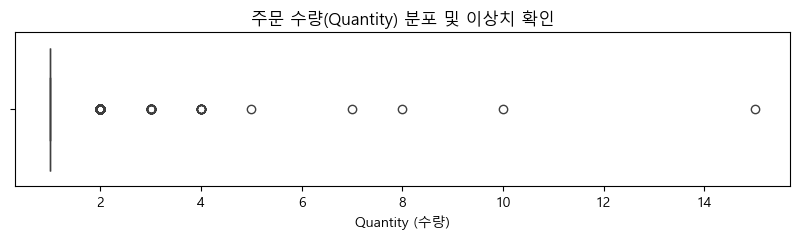

In [99]:
# 수치형 데이터의 이상치 파악
plt.figure(figsize=(10, 2))
sns.boxplot(x=data['quantity'])

plt.title('주문 수량(Quantity) 분포 및 이상치 확인')
plt.xlabel('Quantity (수량)')
plt.show()

In [100]:
# 각 열의 데이터 개수 확인
data.count()

order_id              4622
quantity              4622
item_name             4622
choice_description    3376
item_price            4622
dtype: int64

In [101]:
# 각 열의 고유값의 개수 확인 과정
data["order_id"].value_counts()

order_id
926     23
1483    14
205     12
759     11
1786    11
        ..
768      1
341      1
1048     1
94       1
1199     1
Name: count, Length: 1834, dtype: int64

In [102]:
data["order_id"].value_counts(dropna = False)

order_id
926     23
1483    14
205     12
759     11
1786    11
        ..
768      1
341      1
1048     1
94       1
1199     1
Name: count, Length: 1834, dtype: int64

In [103]:
data["quantity"].value_counts()

quantity
1     4355
2      224
3       28
4       10
5        1
15       1
7        1
8        1
10       1
Name: count, dtype: int64

In [104]:
data["quantity"].value_counts(dropna = False)

quantity
1     4355
2      224
3       28
4       10
5        1
15       1
7        1
8        1
10       1
Name: count, dtype: int64

In [105]:
data["item_name"].value_counts()

item_name
Chicken Bowl                             726
Chicken Burrito                          553
Chips and Guacamole                      479
Steak Burrito                            368
Canned Soft Drink                        301
Steak Bowl                               211
Chips                                    211
Bottled Water                            162
Chicken Soft Tacos                       115
Chips and Fresh Tomato Salsa             110
Chicken Salad Bowl                       110
Canned Soda                              104
Side of Chips                            101
Veggie Burrito                            95
Barbacoa Burrito                          91
Veggie Bowl                               85
Carnitas Bowl                             68
Barbacoa Bowl                             66
Carnitas Burrito                          59
Steak Soft Tacos                          55
6 Pack Soft Drink                         54
Chips and Tomatillo Red Chili Salsa       48


In [106]:
data["item_name"].value_counts(dropna = False)

item_name
Chicken Bowl                             726
Chicken Burrito                          553
Chips and Guacamole                      479
Steak Burrito                            368
Canned Soft Drink                        301
Steak Bowl                               211
Chips                                    211
Bottled Water                            162
Chicken Soft Tacos                       115
Chips and Fresh Tomato Salsa             110
Chicken Salad Bowl                       110
Canned Soda                              104
Side of Chips                            101
Veggie Burrito                            95
Barbacoa Burrito                          91
Veggie Bowl                               85
Carnitas Bowl                             68
Barbacoa Bowl                             66
Carnitas Burrito                          59
Steak Soft Tacos                          55
6 Pack Soft Drink                         54
Chips and Tomatillo Red Chili Salsa       48


In [107]:
data["choice_description"].value_counts()

choice_description
[Diet Coke]                                                                                                                                      134
[Coke]                                                                                                                                           123
[Sprite]                                                                                                                                          77
[Fresh Tomato Salsa, [Rice, Black Beans, Cheese, Sour Cream, Lettuce]]                                                                            42
[Fresh Tomato Salsa, [Rice, Black Beans, Cheese, Sour Cream, Guacamole, Lettuce]]                                                                 40
                                                                                                                                                ... 
[Fresh Tomato Salsa (Mild), [Pinto Beans, Black Beans, Rice, Cheese, Sour Cream, Lettuc

In [108]:
data["choice_description"].value_counts(dropna = False)

choice_description
NaN                                                                                                                                              1246
[Diet Coke]                                                                                                                                       134
[Coke]                                                                                                                                            123
[Sprite]                                                                                                                                           77
[Fresh Tomato Salsa, [Rice, Black Beans, Cheese, Sour Cream, Lettuce]]                                                                             42
                                                                                                                                                 ... 
[Fresh Tomato Salsa (Mild), [Pinto Beans, Black Beans, Rice, Cheese, Sour Cream, 

In [109]:
data["item_price"].value_counts()

item_price
$8.75      730
$11.25     521
$9.25      398
$4.45      349
$8.49      311
          ... 
$13.35       1
$7.50        1
$4.36        1
$11.80       1
$11.49       1
Name: count, Length: 78, dtype: int64

In [110]:
data["item_price"].value_counts(dropna = False)

item_price
$8.75      730
$11.25     521
$9.25      398
$4.45      349
$8.49      311
          ... 
$13.35       1
$7.50        1
$4.36        1
$11.80       1
$11.49       1
Name: count, Length: 78, dtype: int64

In [111]:
# 수치형 데이터의 평균 확인
print(data.mean(numeric_only = True))

order_id    927.254868
quantity      1.075725
dtype: float64


In [112]:
# 수치형 데이터의 중앙값 확인
print(data.median(numeric_only = True))

order_id    926.0
quantity      1.0
dtype: float64


In [113]:
# 수치형 데이터의 최대값 확인
print(data.max(numeric_only = True))

order_id    1834
quantity      15
dtype: int64


In [114]:
# 수치형 데이터의 최소값 확인
print(data.min(numeric_only = True))

order_id    1
quantity    1
dtype: int64


In [115]:
# 수치형 데이터의 표준편차 확인
print(data.std(numeric_only = True))

order_id    528.890796
quantity      0.410186
dtype: float64


In [116]:
# 수치형 데이터의 상관계수 확인
print(data.corr(numeric_only = True))

          order_id  quantity
order_id  1.000000  0.032397
quantity  0.032397  1.000000


## 데이터 전처리 단계

In [117]:
# $를 제거하고 item_price를 실수형으로 전처리
data["item_price"] = data["item_price"].apply(lambda x : float(x.replace("$", "")))

In [118]:
data.head()

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,2.39
1,1,1,Izze,[Clementine],3.39
2,1,1,Nantucket Nectar,[Apple],3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",16.98


In [119]:
# 수치형 데이터의 평균 확인
print(data.mean(numeric_only = True))

order_id      927.254868
quantity        1.075725
item_price      7.464336
dtype: float64


In [120]:
# 수치형 데이터의 중앙값 확인
print(data.median(numeric_only = True))

order_id      926.00
quantity        1.00
item_price      8.75
dtype: float64


In [121]:
# 수치형 데이터의 최대값 확인
print(data.max(numeric_only = True))

order_id      1834.00
quantity        15.00
item_price      44.25
dtype: float64


In [122]:
# 수치형 데이터의 최소값 확인
print(data.min(numeric_only = True))

order_id      1.00
quantity      1.00
item_price    1.09
dtype: float64


In [123]:
# 수치형 데이터의 표준편차 확인
print(data.std(numeric_only = True))

order_id      528.890796
quantity        0.410186
item_price      4.245557
dtype: float64


In [124]:
# 수치형 데이터의 상관계수 확인
print(data.corr(numeric_only = True))

            order_id  quantity  item_price
order_id    1.000000  0.032397   -0.001618
quantity    0.032397  1.000000    0.263981
item_price -0.001618  0.263981    1.000000


## 데이터의 속성 탐색 단계

### 가장 많이 팔린 메뉴 10개 확인하기

In [125]:
top10 = data["item_name"].value_counts().head(10)
print(top10)

item_name
Chicken Bowl                    726
Chicken Burrito                 553
Chips and Guacamole             479
Steak Burrito                   368
Canned Soft Drink               301
Steak Bowl                      211
Chips                           211
Bottled Water                   162
Chicken Soft Tacos              115
Chips and Fresh Tomato Salsa    110
Name: count, dtype: int64


### 주문 1건 당 평균 결제 금액 확인

In [126]:
# 주문의 총합 구하기
order_total = data.groupby("order_id")["item_price"].sum()

print(order_total)

order_id
1       11.56
2       16.98
3       12.67
4       21.00
5       13.70
        ...  
1830    23.00
1831    12.90
1832    13.20
1833    23.50
1834    28.75
Name: item_price, Length: 1834, dtype: float64


## 데이터 시각화 단계

### 가장 많이 팔린 메뉴 10개 확인하는 시각화

In [127]:
# windows용 한글 폰트 오류 해결
from matplotlib import font_manager, rc
font_path = 'C:/Windows/Fonts/malgun.ttf'
font_name = font_manager.FontProperties(fname = font_path).get_name()
rc('font', family=font_name)

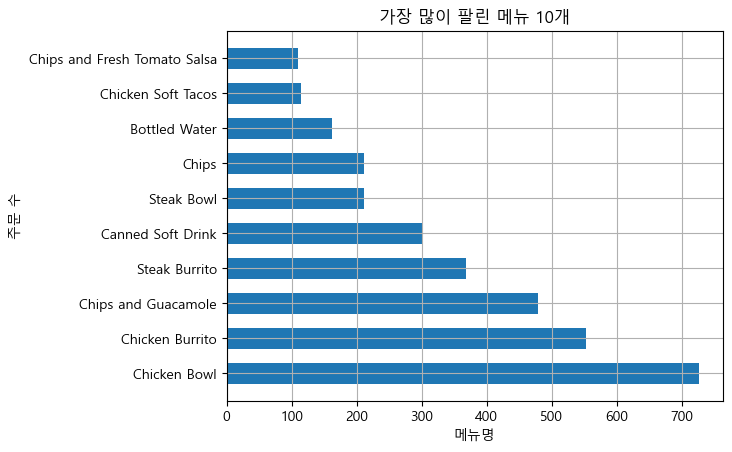

In [128]:
plt.barh(top10.index, top10.values, linewidth = 3,  height = -0.6)

plt.title("가장 많이 팔린 메뉴 10개")
plt.xlabel("메뉴명")
plt.ylabel("주문 수")
plt.grid()

plt.show()

- Chicken Bowl이 700건 이상 주문되어 1등이고 Chicken Burrito가 500건 이상으로 2등입니다.
- 따라서 Chipotle을 방문하는 손님들은 Steak 관련 메뉴보다 Chicken 메뉴를 선호한다는 것을 확인할 수 있습니다.

- Chips and Guacamole과 Canned Soft Drink가 top 5 안에 들어가는 것을 확인할 수 있습니다.
- 따라서 사람들이 메인 요리만을 많이 주문하는 것이 아니라 사이드에 해당하는 음식도 주문을 같이 한다고 예상할 수 있습니다.

### 주문 1건 당 평균 금액 확인 시각화

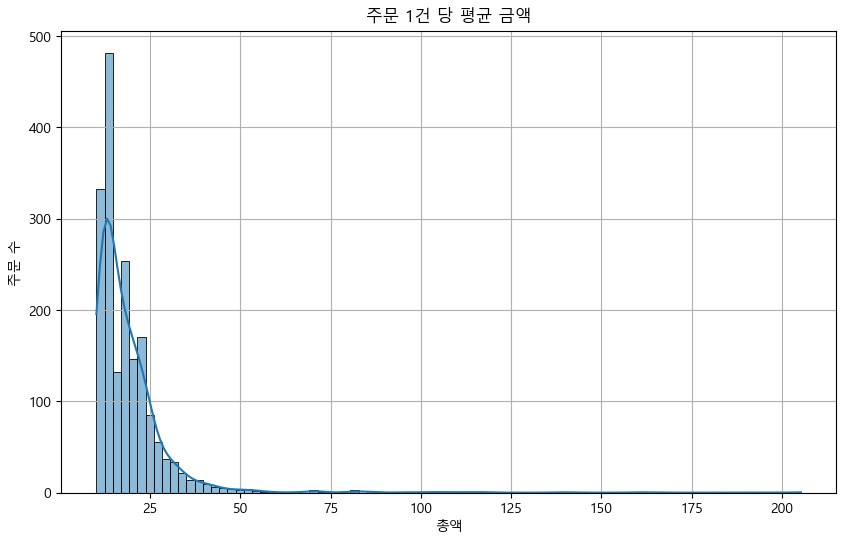

In [129]:
plt.figure(figsize = (10, 6))

sns.histplot(order_total, kde = True)

plt.title("주문 1건 당 평균 금액")
plt.xlabel("총액")
plt.ylabel("주문 수")
plt.grid()

plt.show()

- 그래프의 왼쪽 부분인 10~20달러 사이에 막대가 가장 높게 솟아 있습니다.
- 대다수의 손님들이 Chipotle에 방문하면 한 번에 10~20달러 정도만 사용한다는 것을 확인할 수 있습니다.
- 예상 : 위의 시각화 결과와 함께 봤을 때 메인 메뉴 1개, 사이드 1개를 시키는 1인 방문객이 많다고 예상할 수 있을 것 같습니다.

- 오른쪽으로 갈수록 막대기가 거의 바닥에 붙어서 가는 긴 모양을 보이고 있습니다.
- 단체 주문 손님도 있다고 할 수 있을 것 같습니다.